<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana3/Pandas_EstudioExploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para dividir los datos y construir el modelo
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)

# Para que pandas muestre más columnas cuando inspeccionamos el DataFrame
pd.set_option('display.max_columns', 50)

In [3]:
# Carpeta de trabajo
os.chdir("/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana3")

# Leemos la base completa.
# Es mejor conservar todas las columnas al inicio y seleccionar después
# cuáles necesitaremos para cada análisis.
df = pd.read_csv("Datos/muestra.csv")

print("Dimensiones de la base:", df.shape)
df.head()

Dimensiones de la base: (300, 23)


,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,Ubicación del caso,Estado,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
0,2021-04-23 00:00:00,"2,731,846",2021-04-20 00:00:00,11,BOGOTA,"11,001",BOGOTA,26,1,F,Comunitaria,Casa,Leve,NaN,NaN,Recuperado,2021-04-19 00:00:00,NaN,2021-04-21 00:00:00,2021-05-04 00:00:00,PCR,6,NaN
1,2021-03-31 00:00:00,"2,398,518",2021-03-18 00:00:00,23,CORDOBA,"23,001",MONTERIA,18,1,M,Relacionado,Casa,Leve,NaN,NaN,Recuperado,2021-03-15 00:00:00,NaN,2021-03-29 00:00:00,2021-04-01 00:00:00,Tiempo,6,NaN
2,2021-10-18 00:00:00,"4,981,819",2021-10-03 00:00:00,11,BOGOTA,"11,001",BOGOTA,21,1,F,Relacionado,Casa,Leve,NaN,NaN,Recuperado,2021-09-29 00:00:00,NaN,2021-10-14 00:00:00,2021-10-20 00:00:00,Tiempo,6,NaN
3,2021-02-02 00:00:00,"2,108,069",2021-01-30 00:00:00,11,BOGOTA,"11,001",BOGOTA,39,1,F,Relacionado,Casa,Leve,NaN,NaN,Recuperado,2021-01-28 00:00:00,NaN,2021-01-31 00:00:00,2021-02-11 00:00:00,Tiempo,6,NaN
4,2022-01-11 00:00:00,"5,367,282",2021-12-28 00:00:00,11,BOGOTA,"11,001",BOGOTA,36,1,F,Relacionado,Casa,leve,NaN,NaN,Recuperado,2021-12-24 00:00:00,NaN,2022-01-08 00:00:00,2022-01-12 00:00:00,Tiempo,6,NaN


In [4]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

print("\nColumnas disponibles:")
for columna in df.columns:
    print("-", columna)

Número de filas: 300
Número de columnas: 23

Columnas disponibles:
- fecha reporte web
- ID de caso
- Fecha de notificación
- Código DIVIPOLA departamento
- Nombre departamento
- Código DIVIPOLA municipio
- Nombre municipio
- Edad
- Unidad de medida de edad
- Sexo
- Tipo de contagio
- Ubicación del caso
- Estado
- Código ISO del país
- Nombre del país
- Recuperado
- Fecha de inicio de síntomas
- Fecha de muerte
- Fecha de diagnóstico
- Fecha de recuperación
- Tipo de recuperación
- Pertenencia étnica
- Nombre del grupo étnico


In [5]:
# Limpieza -> valores faltantes, filas repetidas.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   fecha reporte web             300 non-null    object 
 1   ID de caso                    300 non-null    object 
 2   Fecha de notificación         300 non-null    object 
 3   Código DIVIPOLA departamento  300 non-null    object 
 4   Nombre departamento           300 non-null    object 
 5   Código DIVIPOLA municipio     300 non-null    object 
 6   Nombre municipio              300 non-null    object 
 7   Edad                          300 non-null    int64  
 8   Unidad de medida de edad      300 non-null    int64  
 9   Sexo                          300 non-null    object 
 10  Tipo de contagio              300 non-null    object 
 11  Ubicación del caso            298 non-null    object 
 12  Estado                        298 non-null    object 
 13  Códig

In [6]:
# Miremos las variables numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,300.0,40.816667,19.291369,1.0,27.0,38.5,53.0,92.0
Unidad de medida de edad,300.0,1.003333,0.057735,1.0,1.0,1.0,1.0,2.0
Código ISO del país,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre del país,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pertenencia étnica,300.0,5.916667,0.586688,1.0,6.0,6.0,6.0,6.0


In [7]:
# Miremos las variables categoricas
df.describe(include='object').T

,count,unique,top,freq
fecha reporte web,300,206,2022-07-21 00:00:00,5
ID de caso,300,300,"1,723,385",1
Fecha de notificación,300,220,2021-06-15 00:00:00,6
Código DIVIPOLA departamento,300,29,11,103
Nombre departamento,300,29,BOGOTA,103
Código DIVIPOLA municipio,300,83,"11,001",103
Nombre municipio,300,83,BOGOTA,103
Sexo,300,2,F,162
Tipo de contagio,300,2,Comunitaria,214
Ubicación del caso,298,2,Casa,289


In [8]:
# Cantidad de valores faltantes por variable
faltantes = df.isna().sum().sort_values(ascending=False)
faltantes_df = pd.DataFrame({
    'faltantes': faltantes,
    'porcentaje': (faltantes / df.shape[0]) * 100
})
faltantes_df

,faltantes,porcentaje
Código ISO del país,300,100.000000
Nombre del país,300,100.000000
Nombre del grupo étnico,296,98.666667
Fecha de muerte,289,96.333333
Fecha de inicio de síntomas,22,7.333333
Fecha de recuperación,11,3.666667
Tipo de recuperación,11,3.666667
Estado,2,0.666667
Recuperado,2,0.666667
Ubicación del caso,2,0.666667


In [9]:
# Revisamos los registros duplicados
df.duplicated().sum()

np.int64(0)

In [10]:
# Hacemos una copia -> queremos mantener la informacion original
datos = df.copy()

# Pequeña ingenieria de caracteristicas

columnas_texto = [
    'Sexo',
    'Tipo de contagio',
    'Estado',
    'Recuperado',
    'Ubicación del caso'
]

In [11]:
# Quitar los espacios en blanco
for col in columnas_texto:
  if col in datos.columns:
    datos[col] = datos[col].astype('string').str.strip()

In [12]:
# Limpieza
datos['Estado'] = datos['Estado'].str.capitalize()
# evitar tener Leve vs leve
datos['Estado'].value_counts(dropna=False)

,count
Estado,
Leve,289
Fallecido,9
<NA>,2


<Axes: xlabel='Edad', ylabel='Count'>

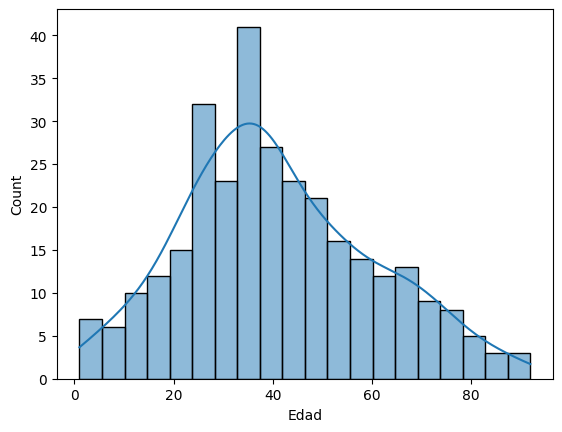

In [13]:
# Analisis exploratorio de datos (EDA)
# Graficar con seaborn
sns.histplot(data=datos, x='Edad', bins=20, kde=True)

In [14]:
# Distribucion de sexo
conteo_sexo = datos['Sexo'].value_counts(dropna=False)
conteo_sexo

,count
Sexo,
F,162
M,138


<Axes: xlabel='Sexo', ylabel='count'>

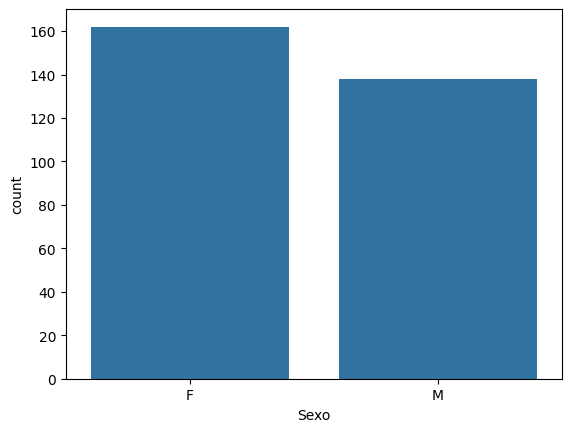

In [15]:
sns.countplot( data=datos, x='Sexo' )

In [16]:
# Tipo de contagio
conteo_tipo_contagio = datos['Tipo de contagio'].value_counts(dropna=False)
conteo_tipo_contagio
# La expertise del analista

,count
Tipo de contagio,
Comunitaria,214
Relacionado,86


<Axes: xlabel='Tipo de contagio', ylabel='count'>

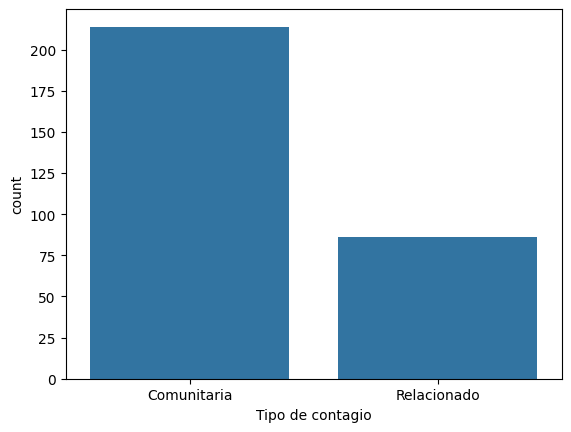

In [17]:
sns.countplot( data=datos, x='Tipo de contagio' )

In [18]:
# El estado del paciente
conteo_estado = datos['Estado'].value_counts(dropna=False)
conteo_estado

,count
Estado,
Leve,289
Fallecido,9
<NA>,2


<Axes: xlabel='Estado', ylabel='count'>

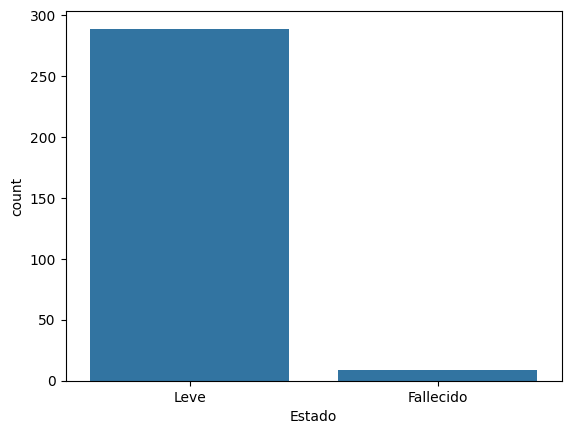

In [19]:
sns.countplot(data=datos, x='Estado')

In [20]:
modelo_df = datos.dropna( subset=['Estado'] ).copy()

# Variables binarias
# Usando un filtro
modelo_df['fallecido'] = (modelo_df['Estado'] == 'Fallecido').astype(int)

modelo_df['fallecido'].value_counts()

,count
fallecido,
0,289
1,9


In [21]:
# Podemos calcular las proporciones
modelo_df['fallecido'].value_counts(normalize=True).rename('proporcion')

,proporcion
fallecido,
0,0.969799
1,0.030201


In [22]:
# Queremos estudiar la probabilidad de que un individuo haya fallecido por la enfermedad dentro de esta muestra

In [23]:
# Exploramos la variable objectivo en terminos de las demas
# Fallecimiento por sexo

In [24]:
# una tabla de contingencia
tabla_sexo = pd.crosstab(
    modelo_df['Sexo'],
    modelo_df['fallecido'],
    margins=True
)
tabla_sexo

fallecido,0,1,All
Sexo,,,
F,159,3,162
M,130,6,136
All,289,9,298


In [25]:
# ============================================================
# PROBABILIDADES A PARTIR DE LA TABLA DE CONTINGENCIA
# ============================================================

# Nuestra tabla:
display(tabla_sexo)

# Número total de individuos
N = tabla_sexo.loc['All', 'All']

print("Número total de individuos:", N)

fallecido,0,1,All
Sexo,,,
F,159,3,162
M,130,6,136
All,289,9,298


Número total de individuos: 298


In [38]:
tabla_sexo.loc['M','All']

np.int64(136)

In [ ]:
# Si sumamos sobre las columnas -> encontrando la distribución marginal del genero
# Si sumamos sobre las filas -> encontrando las dis marginal del resultado de la enfermeda

In [26]:
# ------------------------------------------------------------
# PROBABILIDADES MARGINALES
# ------------------------------------------------------------

# Probabilidad de ser mujer
P_F = tabla_sexo.loc['F', 'All'] / N

# Probabilidad de ser hombre
P_M = tabla_sexo.loc['M', 'All'] / N

# Probabilidad de fallecer
P_D = tabla_sexo.loc['All', 1] / N

# Probabilidad de recuperarse
P_R = tabla_sexo.loc['All', 0] / N


print(f"P(Mujer)       = {P_F:.4f} = {100*P_F:.2f}%")
print(f"P(Hombre)      = {P_M:.4f} = {100*P_M:.2f}%")
print(f"P(Fallecer)    = {P_D:.4f} = {100*P_D:.2f}%")
print(f"P(Recuperarse) = {P_R:.4f} = {100*P_R:.2f}%")

P(Mujer)       = 0.5436 = 54.36%
P(Hombre)      = 0.4564 = 45.64%
P(Fallecer)    = 0.0302 = 3.02%
P(Recuperarse) = 0.9698 = 96.98%


In [39]:
# ------------------------------------------------------------
# PROBABILIDADES CONJUNTAS O DE INTERSECCIÓN
# ------------------------------------------------------------

P_F_R = tabla_sexo.loc['F', 0] / N
P_F_D = tabla_sexo.loc['F', 1] / N

P_M_R = tabla_sexo.loc['M', 0] / N
P_M_D = tabla_sexo.loc['M', 1] / N


print(f"P(Mujer y recupera) = {P_F_R:.4f} = {100*P_F_R:.2f}%")
print(f"P(Mujer y fallece)  = {P_F_D:.4f} = {100*P_F_D:.2f}%")
print(f"P(Hombre y recupera)= {P_M_R:.4f} = {100*P_M_R:.2f}%")
print(f"P(Hombre y fallece) = {P_M_D:.4f} = {100*P_M_D:.2f}%")

P(Mujer y recupera) = 0.5336 = 53.36%
P(Mujer y fallece)  = 0.0101 = 1.01%
P(Hombre y recupera)= 0.4362 = 43.62%
P(Hombre y fallece) = 0.0201 = 2.01%


In [40]:
P_total = P_F_R + P_F_D + P_M_R + P_M_D

print("Suma de las cuatro intersecciones =", P_total)

Suma de las cuatro intersecciones = 0.9999999999999999


In [41]:
# ------------------------------------------------------------
# PROBABILIDADES CONDICIONALES
# ------------------------------------------------------------

# P(Fallecer | Hombre)
P_D_dado_M = (
    tabla_sexo.loc['M', 1]
    / tabla_sexo.loc['M', 'All']
)

# P(Fallecer | Mujer)
P_D_dado_F = (
    tabla_sexo.loc['F', 1]
    / tabla_sexo.loc['F', 'All']
)


print(f"P(Fallecer | Hombre) = {P_D_dado_M:.4f} "
      f"= {100*P_D_dado_M:.2f}%")

print(f"P(Fallecer | Mujer)  = {P_D_dado_F:.4f} "
      f"= {100*P_D_dado_F:.2f}%")

P(Fallecer | Hombre) = 0.0441 = 4.41%
P(Fallecer | Mujer)  = 0.0185 = 1.85%


In [42]:
# P(Mujer | Falleció)

P_F_dado_D = (
    tabla_sexo.loc['F', 1]
    / tabla_sexo.loc['All', 1]
)

# P(Hombre | Falleció)

P_M_dado_D = (
    tabla_sexo.loc['M', 1]
    / tabla_sexo.loc['All', 1]
)


print(f"P(Mujer | Falleció)  = {P_F_dado_D:.4f} "
      f"= {100*P_F_dado_D:.2f}%")

print(f"P(Hombre | Falleció) = {P_M_dado_D:.4f} "
      f"= {100*P_M_dado_D:.2f}%")

P(Mujer | Falleció)  = 0.3333 = 33.33%
P(Hombre | Falleció) = 0.6667 = 66.67%


In [43]:
# ============================================================
# TEOREMA DE BAYES
#
# Queremos calcular:
#
#       P(Mujer | Falleció)
#
# usando:
#
#                         P(Falleció | Mujer) P(Mujer)
# P(Mujer | Falleció) = -----------------------------------
#                              P(Falleció)
# ============================================================


P_F_dado_D_Bayes = (P_D_dado_F * P_F) / P_D


print("Aplicando el teorema de Bayes:")
print()

print(f"P(Fallecer | Mujer) = {P_D_dado_F:.4f}")
print(f"P(Mujer)            = {P_F:.4f}")
print(f"P(Fallecer)         = {P_D:.4f}")

print()

print(f"P(Mujer | Falleció) = {P_F_dado_D_Bayes:.4f}")
print(f"                     = {100*P_F_dado_D_Bayes:.2f}%")

Aplicando el teorema de Bayes:

P(Fallecer | Mujer) = 0.0185
P(Mujer)            = 0.5436
P(Fallecer)         = 0.0302

P(Mujer | Falleció) = 0.3333
                     = 33.33%


In [32]:
# El fallecimiento es independiente del sexo?
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact

# ============================================================
# ¿SEXO Y FALLECIMIENTO SON INDEPENDIENTES?
# ============================================================

# Para las pruebas quitamos los totales ("All")
tabla_prueba = tabla_sexo.loc[['F', 'M'], [0, 1]]

display(tabla_prueba)

fallecido,0,1
Sexo,,
F,159,3
M,130,6


In [44]:
# ------------------------------------------------------------
# PRUEBA CHI-CUADRADO DE INDEPENDENCIA
# ------------------------------------------------------------

chi2, p_chi2, grados_libertad, esperados = chi2_contingency(
    tabla_prueba,
    correction=False
)

print(f"Chi-cuadrado = {chi2:.4f}")
print(f"p-valor      = {p_chi2:.4f}")
print(f"g.l.         = {grados_libertad}")

Chi-cuadrado = 1.6542
p-valor      = 0.1984
g.l.         = 1


In [45]:
tabla_esperados = pd.DataFrame(
    esperados,
    index=['F', 'M'],
    columns=[0, 1]
)

print("Frecuencias esperadas bajo independencia:")
display(tabla_esperados)

Frecuencias esperadas bajo independencia:


,0,1
F,157.107383,4.892617
M,131.892617,4.107383


In [47]:
# ------------------------------------------------------------
# PRUEBA EXACTA DE FISHER
# ------------------------------------------------------------

odds_ratio, p_fisher = fisher_exact(tabla_prueba)

print(f"Odds ratio = {odds_ratio:.4f}")
print(f"p-valor Fisher = {p_fisher:.4f}")

Odds ratio = 2.4462
p-valor Fisher = 0.3091


In [48]:
# Los grupos de edad
# Hacer una estimación de la probabilida con base

In [49]:
#pd.cut() convertir una variable continua en categorias

In [51]:
bins = [0,20,40,60,80,np.inf]
labels = ['0-20','21-40','41-60','61-80','81+']

In [54]:
modelo_df['Grupo edad'] = pd.cut(
    modelo_df['Edad'],
    bins=bins,
    labels=labels,
    include_lowest=True)

In [59]:
# Creamos una estratificación por edad
modelo_df[['Edad','Grupo edad']].head(10)

,Edad,Grupo edad
0,26,21-40
1,18,0-20
2,21,21-40
3,39,21-40
4,36,21-40
5,18,0-20
6,43,41-60
7,89,81+
8,35,21-40
9,63,61-80


In [66]:
modelo_df['fallecido']

,fallecido
0,0
1,0
2,0
3,0
4,0
...,...
295,0
296,0
297,0
298,0


In [68]:
mortalidad_edad = (
    modelo_df
    .groupby('Grupo edad', observed=False)['fallecido'] # Agrupacion
    .agg(['count','sum','mean']) # Agregacion -> metricas
    .rename(columns={
        'count': 'Total',
        'sum': 'Fallecidos',
        'mean': 'frecuancia relativa -> Probabilidad'
    })
)

mortalidad_edad

,Total,Fallecidos,frecuancia relativa -> Probabilidad
Grupo edad,,,
0-20,40,0,0.000000
21-40,129,2,0.015504
41-60,78,0,0.000000
61-80,42,5,0.119048
81+,9,2,0.222222


# Queremos hacer un modelo predictivo
## Usando herramientas machine learning
## Regresión logistica

## QUe variables podemos usar
### Edad, Sexo, Tipo de Contagio, Etnia

## posibles variables
## Ubicación de la persona -> municipio -> vereda
## latitud longitud
## Enfermedades anteriores
## Presion arterial
## Oxigencion
## Inflamacion

## Las que no podemos usar
### Estado, Recupera, Fecha muerte, Tipo de recuperacion

### la fuga de información -> data leakage
## El modelo no debe ver información que no se usa para la prediccion

In [72]:
variables_model = [
    'Edad',
    'Sexo',
    'Tipo de contagio',
    'Pertenencia étnica'
]

X = modelo_df[variables_model].copy()
y = modelo_df['fallecido'].copy()

In [73]:
X

,Edad,Sexo,Tipo de contagio,Pertenencia étnica
0,26,F,Comunitaria,6
1,18,M,Relacionado,6
2,21,F,Relacionado,6
3,39,F,Relacionado,6
4,36,F,Relacionado,6
...,...,...,...,...
295,29,F,Comunitaria,6
296,57,M,Relacionado,6
297,39,M,Comunitaria,6
298,33,M,Relacionado,6


In [74]:
variables_numericas = ['Edad']
variables_categoricas = [
    'Sexo',
    'Tipo de contagio',
    'Pertenencia étnica'
]

preprocesamiento = ColumnTransformer(
    transformers=[
        ('numericas', StandardScaler(), variables_numericas),
        ('categoricas', OneHotEncoder(), variables_categoricas)
    ]
)

In [76]:
preprocesamiento

ColumnTransformer(transformers=[('numericas', StandardScaler(), ['Edad']),
                                ('categoricas', OneHotEncoder(),
                                 ['Sexo', 'Tipo de contagio',
                                  'Pertenencia étnica'])])

In [84]:

# Construirmos el modelo
modelo = LogisticRegression(
    max_iter = 1000,

    # util para problems no balanceados
    class_weight = 'balanced',

    # Semilla para reproducibilidad
    random_state = 42
)

In [86]:
pipeline = Pipeline(
    steps=[
        ('preprocesamiento', preprocesamiento),
        ('modelo', modelo)
    ]
)
pipeline

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Edad']),
                                                 ('categoricas',
                                                  OneHotEncoder(),
                                                  ['Sexo', 'Tipo de contagio',
                                                   'Pertenencia étnica'])])),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [87]:
# Separar los datos en:
# entrenamiento -> el algoritmo aprende
# prueba -> se verifica la generalizacion

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # es un problema no balanceda
)

In [93]:
# Vamos a entrenar el modelo
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Edad']),
                                                 ('categoricas',
                                                  OneHotEncoder(),
                                                  ['Sexo', 'Tipo de contagio',
                                                   'Pertenencia étnica'])])),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])